# Trabalho 2 – Análise Estrutural de Redes Urbanas
### Disciplina: Estrutura de Dados II (DCA3702)

**Região analisada:** Natal, Rio Grande do Norte, Brasil  
**Ferramentas:** OSMnx, NetworkX, Matplotlib, Seaborn

---

## Estrutura do Notebook

Este notebook contém o trabalho original e **cinco abordagens alternativas** que ampliam a análise:

| # | Abordagem | Descrição |
|---|---|---|
| 0 | **Original** | Análise base com métricas obrigatórias |
| 1 | **Comparação entre Bairros** | Análise estrutural comparativa entre regiões de Natal |
| 2 | **Vulnerabilidade da Rede** | Simulação de ataques direcionados vs. aleatórios |
| 3 | **Cruzamento com POIs** | Sobreposição de hubs com pontos de interesse urbano |
| 4 | **Centralidade Ponderada** | Betweenness e closeness com pesos reais de comprimento e velocidade |
| 5 | **Dashboard Comparativo** | Visualização consolidada de todas as métricas |

In [15]:
!pip install osmnx networkx matplotlib nxviz

In [16]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns
import pandas as pd
import osmnx as ox
import warnings

warnings.filterwarnings('ignore')

# Configuração visual padrão
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


In [17]:

# Inicializando com a Zona Norte de Natal-RN
place = "Zona Norte,Natal, Rio Grande do Norte, Brazil"

G = ox.graph_from_place(place, network_type="drive")

print("Carrendando da Zona Norte de Natal\n")
print(G)
print(f"Número de nós: {G.number_of_nodes()}")
print(f"Número de arestas: {G.number_of_edges()}")


Carrendando da Zona Norte de Natal

MultiDiGraph with 7157 nodes and 19869 edges
Número de nós: 7157
Número de arestas: 19869


In [19]:
G_undirected = nx.Graph()

# Copiar nós preservando TODOS os atributos (inclusive x, y, lat, lon)
for node, data in G.nodes(data=True):
    G_undirected.add_node(node, **data)

# Copiar arestas sem duplicar (Graph já trata isso, mas mantemos a verificação)
for u, v, data in G.edges(data=True):
    if not G_undirected.has_edge(u, v):
        G_undirected.add_edge(u, v, **data)

# Remover self-loops
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

# Confirma que é não-direcionado
print(f"Tipo do grafo   : {type(G_undirected).__name__}  ← deve ser 'Graph'")
print(f"Nós             : {G_undirected.number_of_nodes()}")
print(f"Arestas         : {G_undirected.number_of_edges()}")

# Verifica presença de coordenadas nos nós
amostra = list(G_undirected.nodes(data=True))[:1]
no_id, no_data = amostra[0]
print(f"\nAtributos de um nó de exemplo (ID={no_id}):")
for k, v in no_data.items():
    print(f"  {k}: {v}")


Tipo do grafo   : Graph  ← deve ser 'Graph'
Nós             : 7157
Arestas         : 10629

Atributos de um nó de exemplo (ID=314995527):
  y: -5.7452733
  x: -35.2242333
  street_count: 3


In [20]:
#Grau dos Nós e Identificação de Hubs
degree_dict = dict(G_undirected.degree())

# Top 10 hubs por grau
top_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nós por grau (hubs):")
for rank, (node, deg) in enumerate(top_degree, 1):
    print(f"  {rank:2}. Nó {node} → grau {deg}")

Top 10 nós por grau (hubs):
   1. Nó 582071917 → grau 6
   2. Nó 535427704 → grau 5
   3. Nó 558387303 → grau 5
   4. Nó 582091328 → grau 5
   5. Nó 9457010523 → grau 5
   6. Nó 502854733 → grau 4
   7. Nó 502854738 → grau 4
   8. Nó 502854739 → grau 4
   9. Nó 503486188 → grau 4
  10. Nó 503486208 → grau 4


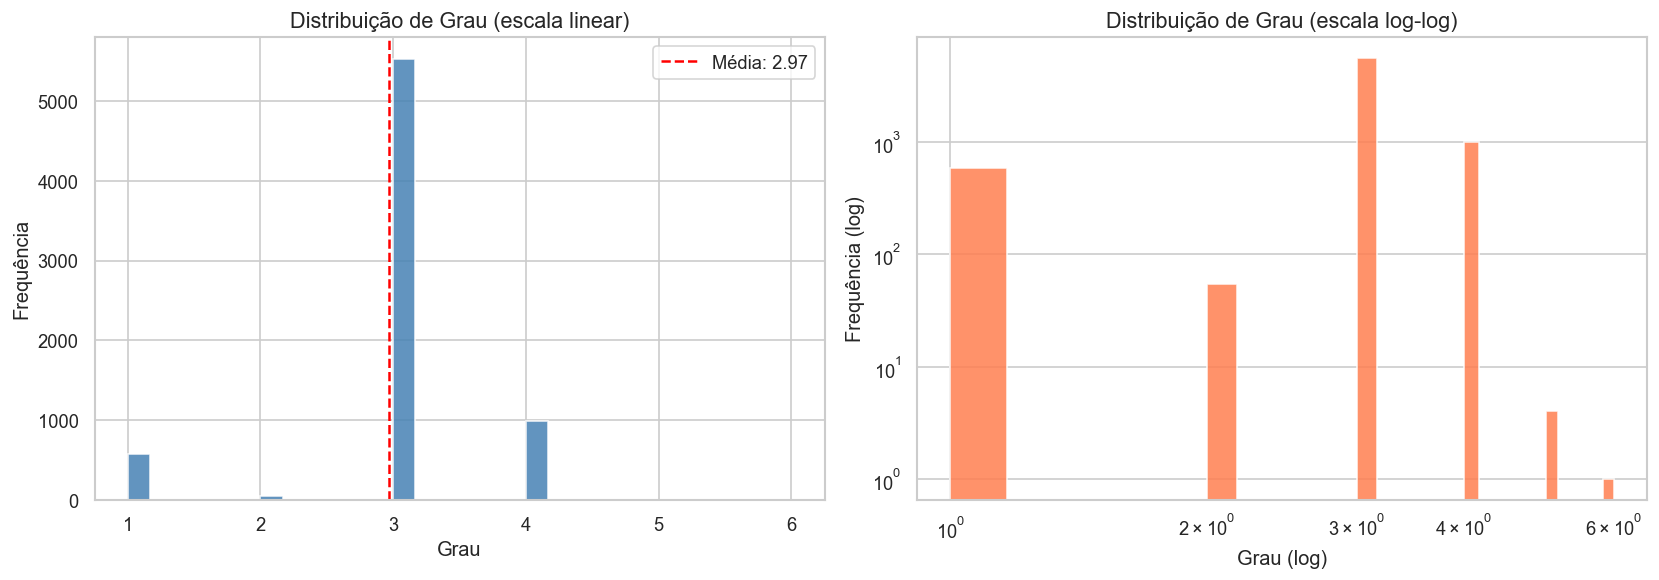

Grau médio   : 2.97
Grau mediano : 3.00
Grau máximo  : 6


In [21]:
# Distribuição de Grau
degrees = list(degree_dict.values())

pfig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma linear
axes[0].hist(degrees, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição de Grau (escala linear)', fontsize=13)
axes[0].set_xlabel('Grau')
axes[0].set_ylabel('Frequência')
axes[0].axvline(np.mean(degrees), color='red', linestyle='--', label=f'Média: {np.mean(degrees):.2f}')
axes[0].legend()

# Histograma log-log (revela lei de potência)
axes[1].hist(degrees, bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].set_title('Distribuição de Grau (escala log-log)', fontsize=13)
axes[1].set_xlabel('Grau (log)')
axes[1].set_ylabel('Frequência (log)')

plt.tight_layout()
plt.savefig('distribuicao_grau.png', bbox_inches='tight')
plt.show()

print(f"Grau médio   : {np.mean(degrees):.2f}")
print(f"Grau mediano : {np.median(degrees):.2f}")
print(f"Grau máximo  : {max(degrees)}")


In [22]:
# Criar o  betweenness
print("Calculando betweenness (aproximado)...")
betweenness = nx.betweenness_centrality(G_undirected, k=500, normalized=True, seed=42)

top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 nós por betweenness:")
for rank, (node, val) in enumerate(top_betweenness, 1):
    print(f"  {rank:2}. Nó {node} → {val:.6f}")

Calculando betweenness (aproximado)...

Top 10 nós por betweenness:
   1. Nó 542878211 → 0.142861
   2. Nó 7613140259 → 0.139010
   3. Nó 2012769761 → 0.137961
   4. Nó 7161594445 → 0.136772
   5. Nó 3800830555 → 0.136719
   6. Nó 544491602 → 0.131632
   7. Nó 544491704 → 0.131164
   8. Nó 1938124616 → 0.125528
   9. Nó 6267738601 → 0.122768
  10. Nó 1876974689 → 0.121745


In [23]:
# Criar o  closeness
print("Calculando closeness centrality...")
closeness = nx.closeness_centrality(G_undirected)

top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 nós por closeness:")
for rank, (node, val) in enumerate(top_closeness, 1):
    print(f"  {rank:2}. Nó {node} → {val:.6f}")

Calculando closeness centrality...

Top 10 nós por closeness:
   1. Nó 7613140259 → 0.030621
   2. Nó 544491602 → 0.030558
   3. Nó 2012769761 → 0.030540
   4. Nó 3134888444 → 0.030400
   5. Nó 3800830555 → 0.030322
   6. Nó 544491608 → 0.030281
   7. Nó 544491601 → 0.030142
   8. Nó 9544033857 → 0.030117
   9. Nó 4555701767 → 0.030101
  10. Nó 544491603 → 0.030031


In [25]:
core_number = nx.core_number(G_undirected)
max_core = max(core_number.values())

k_core_graph = nx.k_core(G_undirected, k=max_core)

print(f"Maior core number (k-max): {max_core}")
print(f"Nós no k-core máximo     : {k_core_graph.number_of_nodes()}")
print(f"Arestas no k-core máximo : {k_core_graph.number_of_edges()}")
print(f"\nDistribuição dos core numbers:")

# Distribuição dos core numbers
core_counts = pd.Series(core_number.values()).value_counts().sort_index()
print(core_counts)

Maior core number (k-max): 2
Nós no k-core máximo     : 6537
Arestas no k-core máximo : 10009

Distribuição dos core numbers:
1     620
2    6537
Name: count, dtype: int64


In [27]:
# Adicionar métricas aos nós
nx.set_node_attributes(G_undirected, degree_dict, "degree")
nx.set_node_attributes(G_undirected, betweenness, "betweenness")
nx.set_node_attributes(G_undirected, closeness, "closeness")
nx.set_node_attributes(G_undirected, core_number, "core_number")

# Renomear x/y -> longitude/latitude para compatibilidade com Gephi Geo Layout
for node, data in G_undirected.nodes(data=True):
    if "x" in data:
        data["longitude"] = data["x"]
    if "y" in data:
        data["latitude"] = data["y"]


# Limpar atributos incompatíveis das arestas
for u, v, data in G_undirected.edges(data=True):

    atributos_remover = []

    for key, value in data.items():

        # Remover geometrias
        if key == "geometry":
            atributos_remover.append(key)

        # Remover listas
        elif isinstance(value, list):
            atributos_remover.append(key)

        # Remover tipos complexos
        elif not isinstance(value, (str, int, float, bool)):
            atributos_remover.append(key)

    for key in atributos_remover:
        del data[key]

# Limpar atributos incompatíveis dos nós
for node, data in G_undirected.nodes(data=True):

    atributos_remover = []

    for key, value in data.items():

        if not isinstance(value, (str, int, float, bool)):
            atributos_remover.append(key)

    for key in atributos_remover:
        del data[key]

# Exportar GraphML compatível com Gephi
nx.write_graphml(G_undirected, "ZN_Natal.graphml")

print("Arquivo 'ZN_Natal.graphml' exportado com sucesso!")

Arquivo 'ZN_Natal.graphml' exportado com sucesso!
